In [1]:
import dataclasses
import json

import colorcet
import einops
import h5py
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats

from lib.plots import set_axis, faint_color, reverse_legend
from lib.stats import fit_power_law

In [28]:
task_ids = {
    "48":        "48-control",
    "49":        "49-control",
    "50-noc":    "50-nocohesin",
    "51-ac":     "51-ac",
    "52-ac":     "52-ac",
    "53-ac_noc": "53-ac_nocohesin",
}

In [29]:
@dataclasses.dataclass
class Metrics:
    files: list[str]
    config: dict
    site_msds: np.ndarray
    domain_rgs: np.ndarray
    domain_distances: np.ndarray
    separation_scores: np.ndarray
    mixing_scores: np.ndarray

conds_metrics = {}

for key, task_id in task_ids.items():
    with h5py.File(f"{task_id}/_outputs/metrics-nocen.h5", "r") as store:
        conds_metrics[key] = Metrics(
            files=[s.decode() for s in store["files"][()]],
            config=json.loads(store["config"][()]),
            site_msds=store["site_msds"][:, :, :],
            domain_rgs=store["domain_rgs"][:],
            domain_distances=store["domain_distances"][:],
            separation_scores=store["separation_scores"][:],
            mixing_scores=(1 / store["separation_scores"][:]),
        )

In [30]:
@dataclasses.dataclass
class MSDAnalysis:
    samples: np.ndarray # (*, time)
    lags: np.ndarray    # (time)
    means: np.ndarray   # (time)
    stds: np.ndarray    # (time)
    alpha: float
    beta: float


def analyze_msd(
    metrics: Metrics,
    max_lag: int,
    replicate_wise: bool,
) -> MSDAnalysis:
    config = metrics.config
    sampling_config = config["sampling"]
    phase_overrides = sampling_config["phases"][-1]
    phase_config = {**sampling_config, **phase_overrides}
    frame_interval = phase_config["timestep"] * phase_config["sampling_interval"]

    site_msds = metrics.site_msds[:, :max_lag + 1, :]
    lags = np.arange(site_msds.shape[1]) * frame_interval

    if replicate_wise:
        samples = site_msds.mean(axis=2)
    else:
        samples = einops.rearrange(site_msds, "r t s -> (r s) t")

    means = samples.mean(axis=0)
    stds = samples.std(axis=0)

    x = lags
    y = means
    alpha, beta = fit_power_law(x, y)

    return MSDAnalysis(
        samples=samples,
        lags=lags,
        means=means,
        stds=stds,
        alpha=alpha,
        beta=beta,
    )

In [31]:
reference_lag = 10

conds_whole_msds = {}
conds_replicate_msds = {}

for key, metrics in conds_metrics.items():
    conds_whole_msds[key] = analyze_msd(
        metrics, max_lag=reference_lag, replicate_wise=False,
    )
    conds_replicate_msds[key] = analyze_msd(
        metrics, max_lag=reference_lag, replicate_wise=True,
    )

In [108]:
@dataclasses.dataclass
class ConditionSpec:
    key:    str
    color:  any
    offset: float
    label:  str


conditions = [
    ConditionSpec(key="48",     color="k", offset=1, label="control"),
    ConditionSpec(key="50-noc", color="r", offset=2, label="Δcohesin"),
]
figure_key = "main"

#conditions = [
#    ConditionSpec(key="49",     color="C:m", offset=1, label="random"),
#    ConditionSpec(key="48",     color="k",   offset=2, label="no crossing"),
#    ConditionSpec(key="50-noc", color="r",   offset=3, label="Δcohesin"),
#]
#figure_key = "crossability"

#conditions = [
#    ConditionSpec(key="52-ac",     color="C:g",  offset=1, label="ac++, random"),
#    ConditionSpec(key="51-ac",     color="#888", offset=2, label="ac++, no crossing"),
#    ConditionSpec(key="53-ac_noc", color="C:y",  offset=3, label="ac++, Δcohesin"),
#]
#figure_key = "acetyl"

In [109]:
for cond in conditions:
    msd = conds_whole_msds[cond.key]
    print("{:15s} α={:.3f} Deff={:.3g}".format(cond.label, msd.alpha, msd.beta))

control         α=0.525 Deff=14.7
Δcohesin        α=0.544 Deff=17


In [110]:
reference_cond = conditions[-1]

print("MSD:")
for cond in conditions:
    msd_fold_change = (
        conds_whole_msds[reference_cond.key].means[-1] /
        conds_whole_msds[cond.key].means[-1]
    )
    print("  {:15s} {:.2f}x".format(cond.label, msd_fold_change))

print("Mixing:")
for cond in conditions:
    mixing_fold_change = (
        conds_metrics[reference_cond.key].mixing_scores.mean() /
        conds_metrics[cond.key].mixing_scores.mean()
    )
    print("  {:15s} {:.2f}x".format(cond.label, mixing_fold_change))

MSD:
  control         1.15x
  Δcohesin        1.00x
Mixing:
  control         1.20x
  Δcohesin        1.00x


In [111]:
print("MSD:")

for i, cond_i in enumerate(conditions):
    for j, cond_j in enumerate(conditions):
        if i >= j:
            continue
        whole_test = scipy.stats.ttest_rel(
            conds_whole_msds[cond_i.key].samples[:, -1],
            conds_whole_msds[cond_j.key].samples[:, -1],
        )
        replicate_wise_test = scipy.stats.ttest_rel(
            conds_replicate_msds[cond_i.key].samples[:, -1],
            conds_replicate_msds[cond_j.key].samples[:, -1],
        )
        print(cond_i.label, "vs", cond_j.label)
        print("  whole   p = {:.3g}".format(whole_test.pvalue))
        print("  repwise p = {:.3g}".format(replicate_wise_test.pvalue))

MSD:
control vs Δcohesin
  whole   p = 1.11e-188
  repwise p = 7.91e-06


In [112]:
print("Mixing score:")

for i, cond_i in enumerate(conditions):
    for j, cond_j in enumerate(conditions):
        if i >= j:
            continue
        whole_test = scipy.stats.ttest_ind(
            conds_metrics[cond_i.key].mixing_scores.ravel(),
            conds_metrics[cond_j.key].mixing_scores.ravel(),
        )
        replicate_wise_test = scipy.stats.ttest_ind(
            conds_metrics[cond_i.key].mixing_scores.mean(axis=-1),
            conds_metrics[cond_j.key].mixing_scores.mean(axis=-1),
        )
        print(cond_i.label, "vs", cond_j.label)
        print("  whole   p = {:.3g}".format(whole_test.pvalue))
        print("  repwise p = {:.3g}".format(replicate_wise_test.pvalue))

Mixing score:
control vs Δcohesin
  whole   p = 0
  repwise p = 1.64e-08


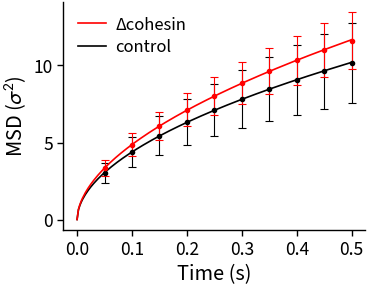

In [121]:
replicate_wise = False

fig, ax = plt.subplots(figsize=(1.9, 1.5))

for cond in conditions:
    if replicate_wise:
        msd = conds_replicate_msds[cond.key]
    else:
        msd = conds_whole_msds[cond.key]

    x = msd.lags[1:]
    y = msd.means[1:]
    y_err = msd.stds[1:]
    ax.errorbar(
        x, y, y_err,
        color=cond.color,
        marker="o",
        markersize=1,
        linewidth=0,
        elinewidth=0.4,
        capsize=1.3,
        capthick=0.4,
        zorder=2,
    )

    x = np.linspace(msd.lags[0], msd.lags[-1], num=200)
    y = x**msd.alpha * msd.beta
    ax.plot(x, y, lw=0.6, color=cond.color, label=cond.label)

ax.legend()
reverse_legend(ax)

ax.set_xticks(np.arange(0, 0.51, 0.1))
ax.set_xlabel(r"Time (s)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")

set_axis(ax, "left bottom")

if replicate_wise:
    suffix = "-repwise"
else:
    suffix = "-whole"

fig.savefig(f"_figs/MSD_curve-{figure_key}{suffix}.svg")

pass

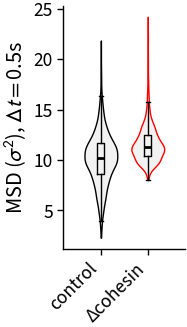

In [122]:
fig, ax = plt.subplots(figsize=(1.0, 1.7))

data = [
    conds_whole_msds[cond.key].samples[:, -1]
    for cond in conditions
]
xs = [cond.offset for cond in conditions]

violins = ax.violinplot(
    data,
    xs,
    widths=0.7,
    showextrema=False,
    showmedians=False,
)

for cond, body in zip(conditions, violins["bodies"]):
    body.set_facecolor("0.95")
    body.set_edgecolor(cond.color)
    body.set_alpha(1)

ax.boxplot(
    data,
    positions=xs,
    showbox=True,
    showcaps=True,
    showfliers=False,
    capprops=dict(linewidth=0.5, color="k"),
    whiskerprops=dict(linewidth=0.5, color="k"),
    boxprops=dict(linewidth=0.5, color="k"),
    medianprops=dict(linewidth=1, color="k"),
)

ax.set_xticks(xs)
ax.set_xticklabels([cond.label for cond in conditions], ha="right", rotation=45)
ax.set_ylabel(r"MSD ($ \sigma^2 $), $ \Delta t = $0.5s")

ax.set_xlim(0.2, len(conditions) + 0.8)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/MSD_violin-{figure_key}.svg")

pass

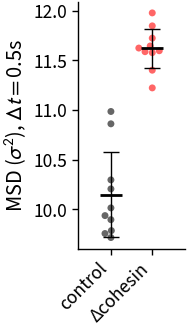

In [123]:
fig, ax = plt.subplots(figsize=(1.0, 1.7))

sns.swarmplot(
    {
        cond.label: conds_replicate_msds[cond.key].samples[:, -1]
        for cond in conditions
    },
    palette=[faint_color(cond.color, 0.4) for cond in conditions],
    size=2.5,
    zorder=1,
    ax=ax,
)

ax.errorbar(
    np.arange(len(conditions)),
    [conds_replicate_msds[cond.key].means[-1] for cond in conditions],
    [conds_replicate_msds[cond.key].stds[-1] for cond in conditions],
    linestyle="none",
    marker="_",
    markersize=8,
    capsize=3,
    capthick=0.5,
    elinewidth=0.5,
    color="k",
    zorder=2,
)

for label_text in ax.get_xticklabels():
    label_text.set_rotation(45)
    label_text.set_horizontalalignment("right")

ax.set_ylabel(r"MSD ($ \sigma^2 $), $ \Delta t = $0.5s")

ax.set_xlim(-0.8, len(conditions) - 0.2)
 
set_axis(ax, "left bottom")

fig.savefig(f"_figs/MSD_swarm-{figure_key}.svg")

pass

In [141]:
msd_a = conds_replicate_msds["48"]
msd_b = conds_replicate_msds["50-noc"]
scipy.stats.ttest_ind_from_stats(
    msd_a.means[-1], msd_a.stds[-1], 10,
    msd_b.means[-1], msd_a.stds[-1], 10,
)
scipy.stats.ttest_rel(msd_a.samples[:, -1], msd_b.samples[:, -1])

TtestResult(statistic=-9.083771452845284, pvalue=7.914349196784712e-06, df=9)

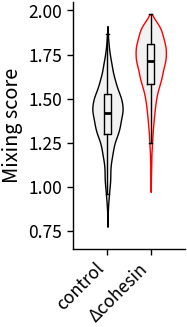

In [124]:
fig, ax = plt.subplots(figsize=(1.0, 1.7))

data = [
    conds_metrics[cond.key].mixing_scores.ravel()
    for cond in conditions
]
xs = [cond.offset for cond in conditions]

violins = ax.violinplot(
    data,
    positions=xs,
    widths=0.7,
    showextrema=False,
)

for cond, body in zip(conditions, violins["bodies"]):
    body.set_facecolor("0.95")
    body.set_edgecolor(cond.color)
    body.set_alpha(1)

ax.boxplot(
    data,
    positions=xs,
    showbox=True,
    showcaps=True,
    showfliers=False,
    capprops=dict(linewidth=0.5, color="k"),
    whiskerprops=dict(linewidth=0.5, color="k"),
    boxprops=dict(linewidth=0.5, color="k"),
    medianprops=dict(linewidth=1, color="k"),
)

ax.set_xticks(xs)
ax.set_xticklabels([cond.label for cond in conditions], ha="right", rotation=45)
ax.set_ylabel("Mixing score")
ax.set_xlim(0.2, len(conditions) + 0.8)
ax.set_ylim(0.65, 2.05)

set_axis(ax, "left bottom")

fig.savefig(f"_figs/Mixing_violin-{figure_key}.svg")

pass